## Time-Series Analysis and Multi Linear Regression Modeling
The model will be trained using pandas and scikit-learn.
The model will be trained from data found at https://www.kaggle.com/datasets/arashnic/cinema-ticket

I am running this through VS Code, using a docker container. You may also use the `ipynb` file in other Jupyter Notebook style setups. Consult Jupyter Notebook for options.

**To download the data, run this cell.**

Running this cell will download the data, if you are running it in the docker container. If not, you will need to navigate to the `KAGGLE_DATA_URL` and download the data manually.

In [1]:
import os
from data import download_kaggle_dataset
KAGGLE_DATA_URL = "https://www.kaggle.com/datasets/arashnic/cinema-ticket"
DATA_PATH = os.path.join(os.getcwd(), "data", "time_series_analysis")
download_kaggle_dataset(KAGGLE_DATA_URL, DATA_PATH)

/workspaces/MS365/src/data/time_series_analysis contains data. Delete the file(s) if you want to download again.


/usr/local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Import the necessary python packages**

Import `pandas`, `statsmodels.tsa.seasonal.seasonal_decompose`, `sklearn.linear_model.LinearRegression`, `sklearn.metrics.mean_absolute_error`, `sklearn.metrics.mean_squared_error`, and `matplotlib.pyplot`. Typically, packages such as `pandas`, `numpy`, and `matplotlib.pyplot` are imported with an allias. I will not be following that strategy here. 

The default size of the plots from `matplotlib.pyplot` is 6.4 inches by 4.8 inches ([width by height](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html)). I wll be setting them to 20 inches by 5 inches. This will create a more readable output. Depending on your screen size, you may want to change this for your own use. 

By default, `pandas` will truncate datasets with a lot of rows and a lot of columns. You can alter this functionality with the `set_option()` function. I have set it to show all possible columns. This could result in long run times for cells where you are displaying the data, if there are many columns to display. This will be expected behavior for this analysis.

If you are running the docker container or if you are using [Google Colab](https://colab.research.google.com/), the `pip install` has already been done. If not, then please consult your jupyter notebook environment docs for how to install the needed packages.

In [2]:
import pandas
import matplotlib.pyplot
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot

matplotlib.pyplot.rcParams["figure.figsize"] = [20, 5]
pandas.set_option("display.max_columns", None)

**Import, Review, and Clean Data**

Import the data downloaded from the Kaggle site. The file name is `cinemaTicket_Ref.csv`. Import it into `df` using `pandas.read_csv()`. The file is a typical CSV file, separated by commas.

Display the top rows of the dataframe using the `head()` method. The default value is `n=5`. Change the value if you want to see more or less rows. The example shows the top 15 rows of data.

In [3]:
df = pandas.read_csv(os.path.join(DATA_PATH, "cinemaTicket_Ref.csv"))
df.head(n=15)

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
0,1492,304,3900000,26,0,4,4.26,150000.000000,26,610.328638,2018-05-05,5,2,5
1,1492,352,3360000,42,0,5,8.08,80000.000000,42,519.801980,2018-05-05,5,2,5
2,1492,489,2560000,32,0,4,20.00,80000.000000,32,160.000000,2018-05-05,5,2,5
3,1492,429,1200000,12,0,1,11.01,100000.000000,12,108.991826,2018-05-05,5,2,5
4,1492,524,1200000,15,0,3,16.67,80000.000000,15,89.982004,2018-05-05,5,2,5
5,1492,71,1050000,7,0,3,0.98,150000.000000,7,714.285714,2018-05-05,5,2,5
6,1492,163,1020000,10,0,3,7.69,102000.000000,10,130.039012,2018-05-05,5,2,5
7,1492,450,750000,5,0,3,1.57,150000.000000,5,318.471338,2018-05-05,5,2,5
8,1492,51,750000,11,0,2,0.95,68181.818182,11,1157.894737,2018-05-05,5,2,5
9,1492,522,600000,4,0,3,1.55,150000.000000,4,258.064516,2018-05-05,5,2,5


The top 15 rows of data provide a good example of the data and the potential datatypes. All the values are numerical, with the exception of `date`, which is a date column. This will need to be a `datetime` data type. 

It is also necessary to check for missing data and to verify the overall statistics of each column. Running the [`describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) will show the counts, the mean, the maximum value, the minimum value, and other statistics of the numerical columns. If the `include="all"` parameter is included, then the counts for all columns, including those that are not numerical will be included.

Looking at all the columns, the columns `capacity` and `occu_perc` have a lower count than the other columns. The count will only count values that are not null. This suggests that `capacity` and `occu_perc` contain some missing values. All other columns seem to have all their data points, which is 142,524 rows of data.

In [4]:
df.describe(include="all")

,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,date,month,quarter,day
count,142524.000000,142524.000000,1.425240e+05,142524.000000,142524.000000,142524.000000,142399.000000,142524.000000,142524.000000,142399.000000,142524,142524.000000,142524.000000,142524.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,234,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-15,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,790,NaN,NaN,NaN
mean,1518.985111,320.378427,1.234728e+07,140.137570,0.237413,3.932103,19.965986,81234.599886,139.900157,854.723605,NaN,6.776852,2.634721,16.112585
std,36.184450,159.701229,3.065486e+07,279.758733,2.923206,3.056276,22.653445,33236.599278,279.564935,953.118103,NaN,2.195843,0.809692,8.949471
min,1471.000000,32.000000,2.000000e+04,1.000000,0.000000,1.000000,0.000000,483.870968,-219.000000,-2.000000,NaN,2.000000,1.000000,1.000000
25%,1485.000000,181.000000,1.260000e+06,18.000000,0.000000,2.000000,3.750000,60000.000000,18.000000,276.994486,NaN,5.000000,2.000000,8.000000
50%,1498.000000,324.000000,3.720000e+06,50.000000,0.000000,3.000000,10.350000,79454.235185,50.000000,525.714286,NaN,7.000000,3.000000,16.000000
75%,1556.000000,474.000000,1.110000e+07,143.000000,0.000000,5.000000,28.210000,100000.000000,143.000000,1038.961039,NaN,9.000000,3.000000,24.000000


Review the `dtypes` of each column in the dataframe. The column `date` is an `object` data type. It needs to be a `datetime` data type so it can be used in the time-series analysis. The other columns are fine, for now. The time-series analysis will be a Multiple Linear Regression analysis, which will require numerical data.

In [5]:
df.dtypes

film_code         int64
cinema_code       int64
total_sales       int64
tickets_sold      int64
tickets_out       int64
show_time         int64
occu_perc       float64
ticket_price    float64
ticket_use        int64
capacity        float64
date             object
month             int64
quarter           int64
day               int64
dtype: object

Convert the `date` column to a `datetime` data type using the [`to_datetime()`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) method from `pandas`. There are many parameters that can be used with this method. For the purpose of this change, the default parameters are sufficient. Typing `df.dtypes` again, at the end, will show that the `date` column is now a `datetime` data type.

In [6]:
df.date = pandas.to_datetime(df.date)

df.dtypes

film_code                int64
cinema_code              int64
total_sales              int64
tickets_sold             int64
tickets_out              int64
show_time                int64
occu_perc              float64
ticket_price           float64
ticket_use               int64
capacity               float64
date            datetime64[ns]
month                    int64
quarter                  int64
day                      int64
dtype: object

The `date` column contains many duplicate values. It will be used as the index below, so the data needs to be grouped together, based on the `date` column, and summed. To do this, apply the [`groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) method to `df`, passing in `by=df.date` and `as_index=False`. This will group all the rows by the `date` column. Then, use the [`sum()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html) method to add together all the values in each column by the value in the `date` column. Saving this to the `df` variable will overwrite the previous `df` data, with the newly grouped data.

In [7]:
df = df.groupby(by=df.date, as_index=False).sum()

Rerun the `describe()` method. This will show that all columns now have the same number of rows; `234` rows. The `groupby()` method used above has eliminated all the missing rows of data. It also eliminated some of the anomolous data points, such as the `-2` in `capacity` and `-219` in `ticket_use`, which seem to be bad data. It also eliminates all the `0` values that were the minimum values in some of the other columns. It is possible that those rows of data were useful, but they would have introduced some issues when calculating statistical values in the Linear Regression Model that will be trained below.

In [8]:
df.describe(include="all")

,date,film_code,cinema_code,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity,month,quarter,day
count,234,2.340000e+02,234.000000,2.340000e+02,234.000000,234.000000,234.000000,234.000000,2.340000e+02,234.000000,234.000000,234.000000,234.000000,234.000000
mean,2018-07-08 00:06:09.230769152,9.251788e+05,195135.106838,7.520441e+09,85354.559829,144.602564,2394.952991,12150.155940,4.947812e+07,85209.957265,520135.840398,4127.623932,1604.747863,9813.803419
min,2018-02-21 00:00:00,1.471000e+03,448.000000,1.800000e+05,3.000000,0.000000,1.000000,2.070000,2.500000e+04,3.000000,144.927536,2.000000,1.000000,20.000000
25%,2018-05-09 06:00:00,9.014502e+05,188664.250000,3.636723e+09,40998.000000,71.500000,2420.750000,6882.737500,4.429480e+07,40956.000000,527409.297175,3133.500000,1251.500000,4636.250000
50%,2018-07-08 12:00:00,9.808320e+05,208036.500000,6.156187e+09,67453.000000,118.000000,2557.500000,9697.045000,5.310510e+07,67300.000000,553914.255065,4161.000000,1518.000000,9312.000000
75%,2018-09-04 18:00:00,1.056028e+06,223581.000000,1.079416e+10,119043.000000,187.250000,2649.000000,16100.527500,5.919879e+07,118837.500000,574187.717590,5182.000000,1961.250000,14836.000000
max,2018-11-04 00:00:00,1.183995e+06,254139.000000,2.131939e+10,293781.000000,873.000000,3018.000000,35687.080000,6.981486e+07,293609.000000,659694.741746,7810.000000,3020.000000,22165.000000
std,NaN,2.282974e+05,50390.598783,4.935529e+09,62561.457536,118.967952,556.375774,7825.332851,1.422194e+07,62499.562303,118266.261987,1733.965154,665.810945,6106.964130


Drop the columns that will not be used in the analysis. The first two columns are `film_code` and `cinema_code`. Reviewing the Kaggle site for this data set, it is not clear what these values represent, but based on the names of the columns, it can be assumed that the data represent codes for identifying the film and the building in which the film was presented. Although these columns contain numerical data, they are more likely categorical in nature, so they would not be useful in a Linear Regression model. The other columns that will be dropped are `month`, `quarter`, and `day`. These columns are likely useful, but they will be dropped now, so that we can recreate them later, which will provide the skill and knowledge necessary to perform a time-series analysis on your own. The usefulness of those columns will depend on the kind of time-series analysis to be performed.

Use the [`drop()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) method on `df`. There are many parameters that can be used with this method. For the purpose of this analysis, only `columns=[]` and `inplace=True` will be used. Insert a list of the column names in the `columns` parameter.

Looking at the top 15 rows of data will show that the columns have been dropped.

In [9]:
df.drop(columns=["film_code", "cinema_code", "month", "quarter", "day"], inplace=True)
df.head(n=15)

,date,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity
0,2018-02-21,32030000,267,0,2,47.76,1.199625e+05,267,559.045226
1,2018-02-23,180000,3,0,1,2.07,6.000000e+04,3,144.927536
2,2018-03-14,2202300484,20104,30,981,1833.27,1.648094e+07,20074,201009.097319
3,2018-03-15,4479008974,41274,33,1305,3909.72,2.307049e+07,41241,269355.809792
4,2018-03-16,5386645987,51761,76,1556,5215.10,2.737739e+07,51685,335681.613312
5,2018-03-17,3367302992,38026,32,1701,4535.76,2.754843e+07,37994,379789.308332
6,2018-03-18,3298541496,34424,102,1809,4222.12,3.172340e+07,34322,409369.006835
7,2018-03-19,3232929498,33078,58,1835,4278.34,3.276363e+07,33020,407062.147114
8,2018-03-20,259605000,4028,14,654,866.07,9.912798e+06,4014,174232.278305
9,2018-03-21,5901486491,50695,48,1327,8957.45,3.678998e+07,50647,296457.493027


Sort the `date` column using the [`sort_values()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) method. There are many parameters that can be used. Review the documentation if you want to learn more about it. For the purpose of this analysis, passing in `by="date"` and `inplace=True` will sort the date column from oldest to newest.

Change the index of the dataframe from numbers to the `date` column. This will allow us to perform an analysis based on the dates. Use [`set_index()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html), passing in the column you want to set as the index and the `inplace=True` parameter. 

The top 15 lines of the dataframe will show the change that has just happened. In the cell above, the index are values 0-14, but in the cell below, the index is now the dates `2018-02-21`, `2018-02-23`, `2018-03-14`, and others. 

In [10]:
df.sort_values(by="date", inplace=True)
df.set_index("date", inplace=True)
df.head(n=15)

,total_sales,tickets_sold,tickets_out,show_time,occu_perc,ticket_price,ticket_use,capacity
date,,,,,,,,
2018-02-21,32030000,267,0,2,47.76,1.199625e+05,267,559.045226
2018-02-23,180000,3,0,1,2.07,6.000000e+04,3,144.927536
2018-03-14,2202300484,20104,30,981,1833.27,1.648094e+07,20074,201009.097319
2018-03-15,4479008974,41274,33,1305,3909.72,2.307049e+07,41241,269355.809792
2018-03-16,5386645987,51761,76,1556,5215.10,2.737739e+07,51685,335681.613312
2018-03-17,3367302992,38026,32,1701,4535.76,2.754843e+07,37994,379789.308332
2018-03-18,3298541496,34424,102,1809,4222.12,3.172340e+07,34322,409369.006835
2018-03-19,3232929498,33078,58,1835,4278.34,3.276363e+07,33020,407062.147114
2018-03-20,259605000,4028,14,654,866.07,9.912798e+06,4014,174232.278305


**Plot the data**

Plot the data to show what it looks like, based on the index of the dataframe. Each of the data points are on a different scale. Placing them all in one plot would remove the readability of the plot. Thus, a plot will be created for each of the columns.

Loop through each of the columns using the `df.columns` attribute. Change the name of the column, removing the underscore with `replace()` and capitalizing each of the words with the `title()` function. Save it to the variable called `label`. Use `matplotlib.pyplot` to create a `plot()`, adding a `title()`, `xlabel()`, `ylabel()`, `legend()`, and `xticks()`. This will make the plots more readable. The [`xticks()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html) method is useful when you want to indicate what the values should by along the x-axis. For these plots, I will show the date, rotated to a 45 degree angle, with a [`date_range()`](https://pandas.pydata.org/docs/reference/api/pandas.date_range.html) from the first date to the last date of the index, separated by week.

The plots show some patterns of highs and lows, with what seems to be some common signals. There are typically four components of a time-series analysis: level, trend, seasonality, and noise. Each will be discussed in more detail below, as we walk through the decomposition of time-series data.

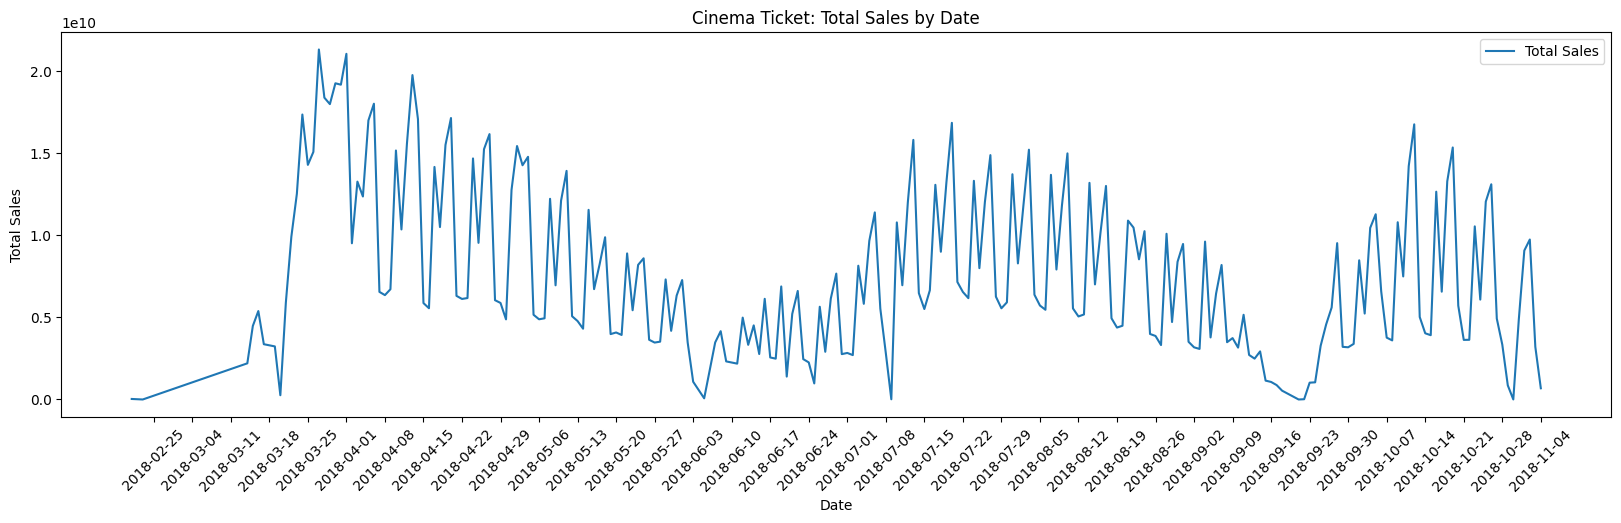

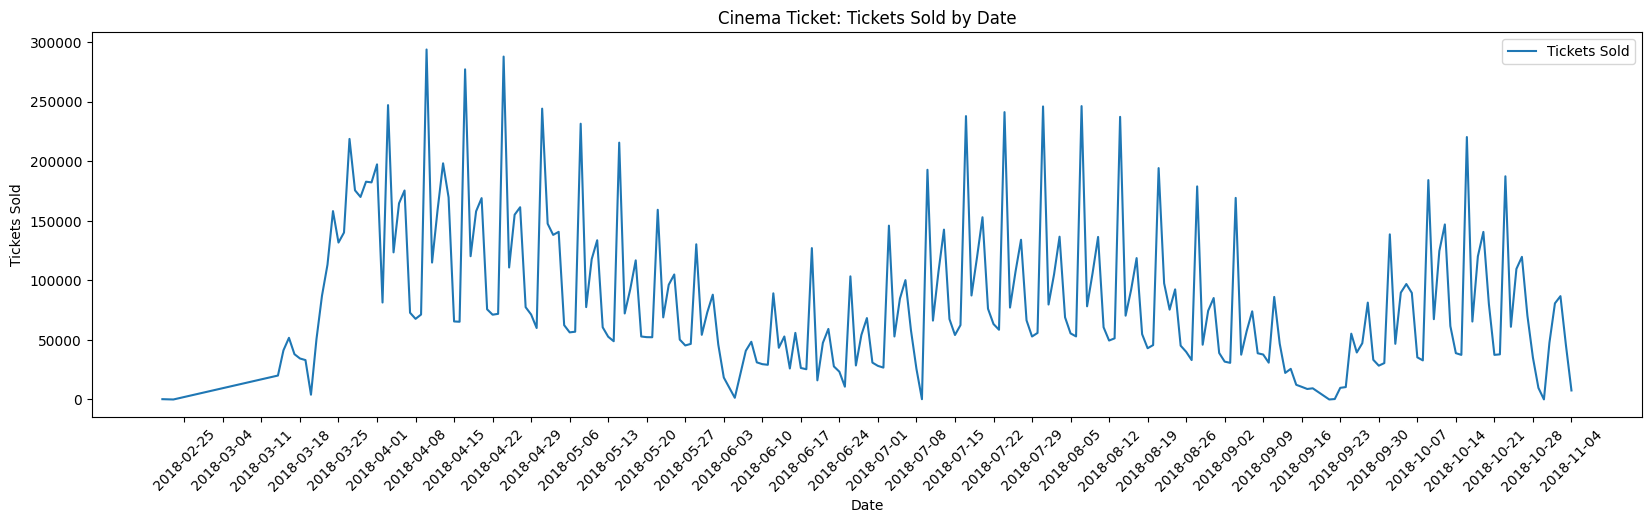

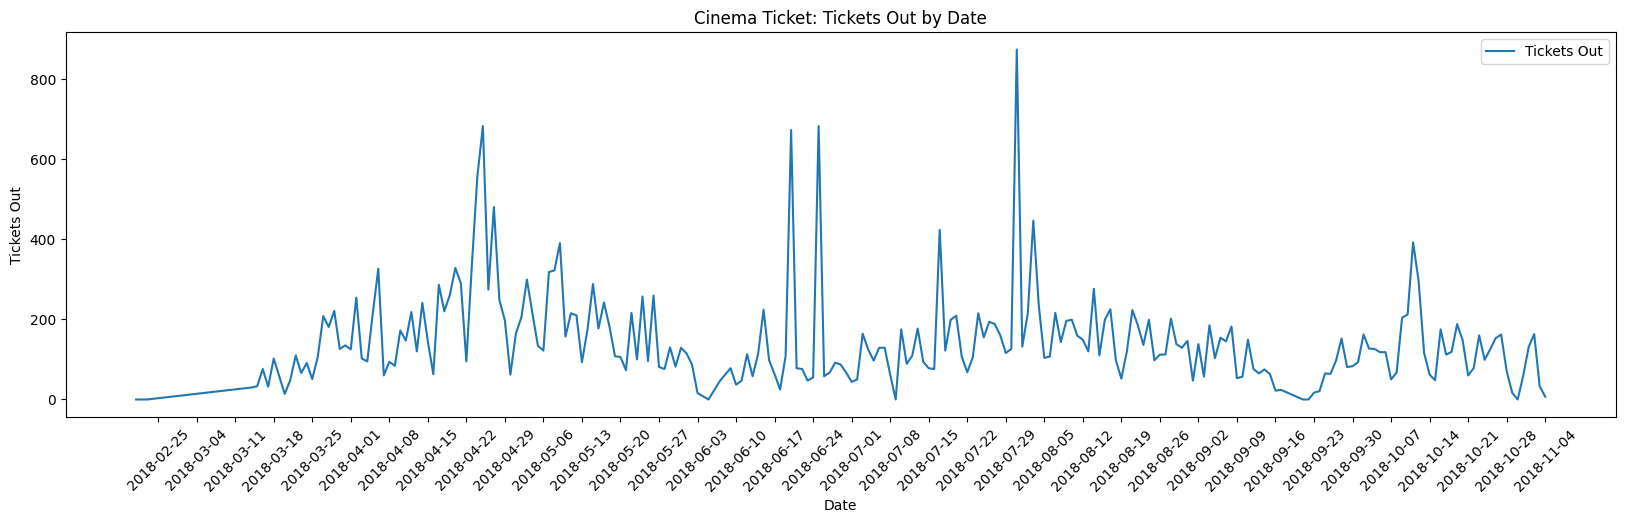

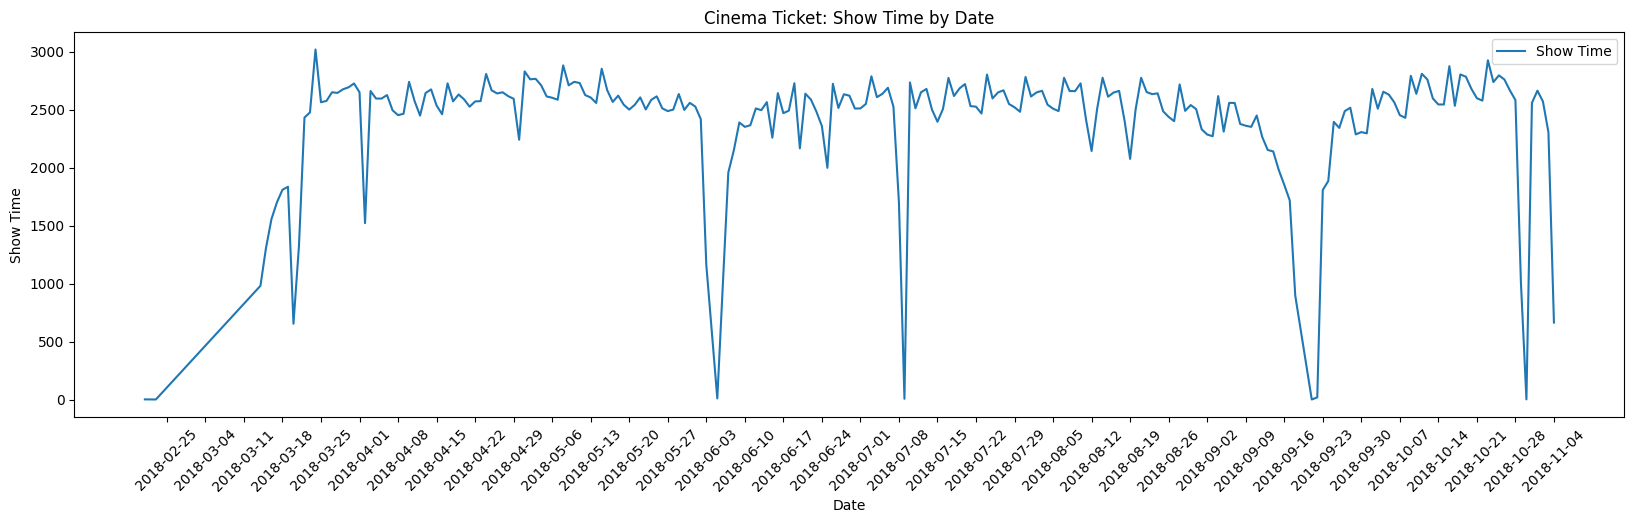

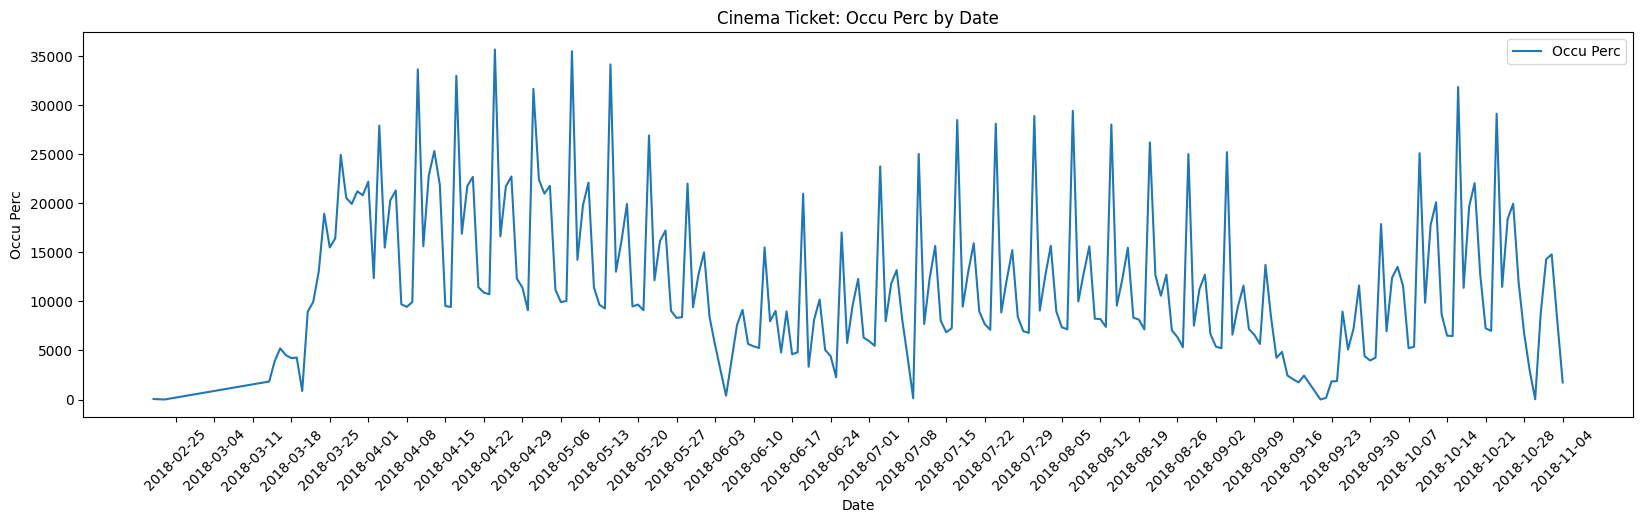

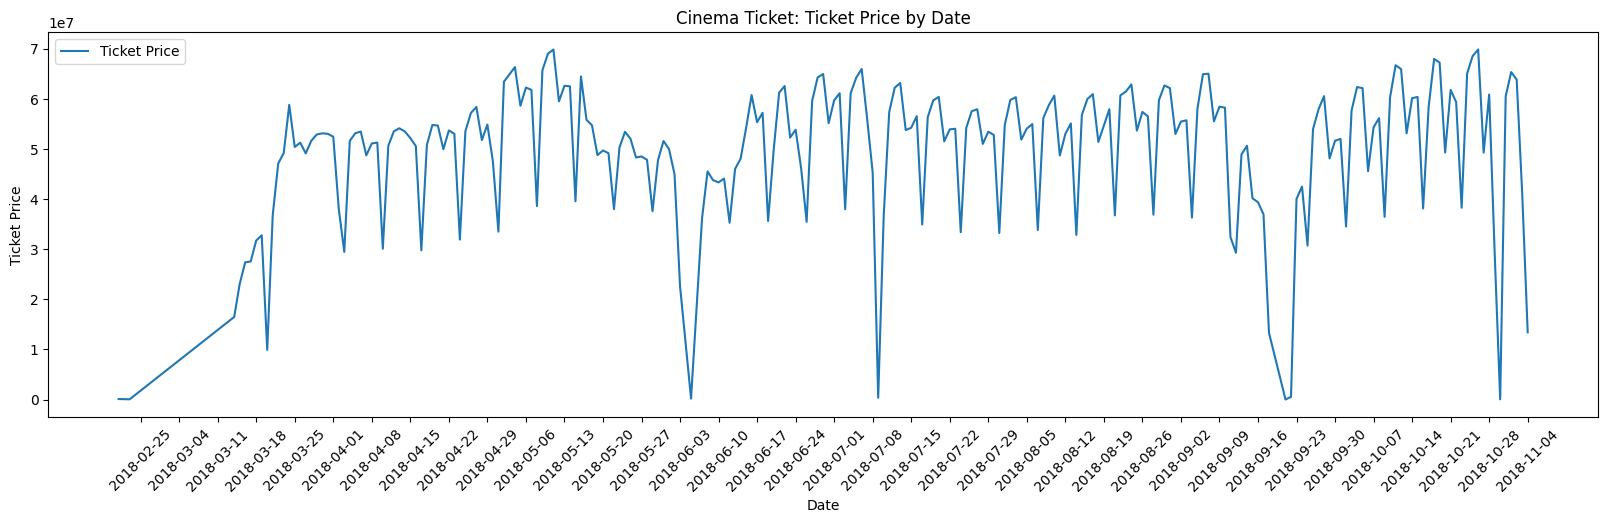

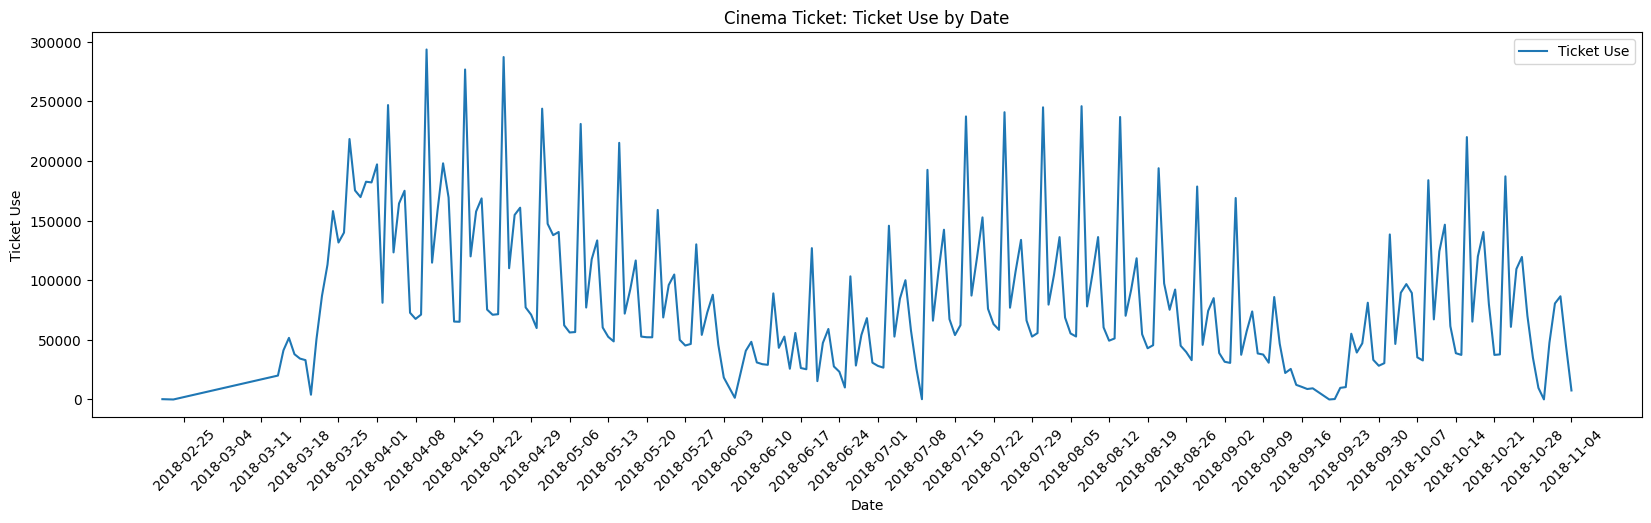

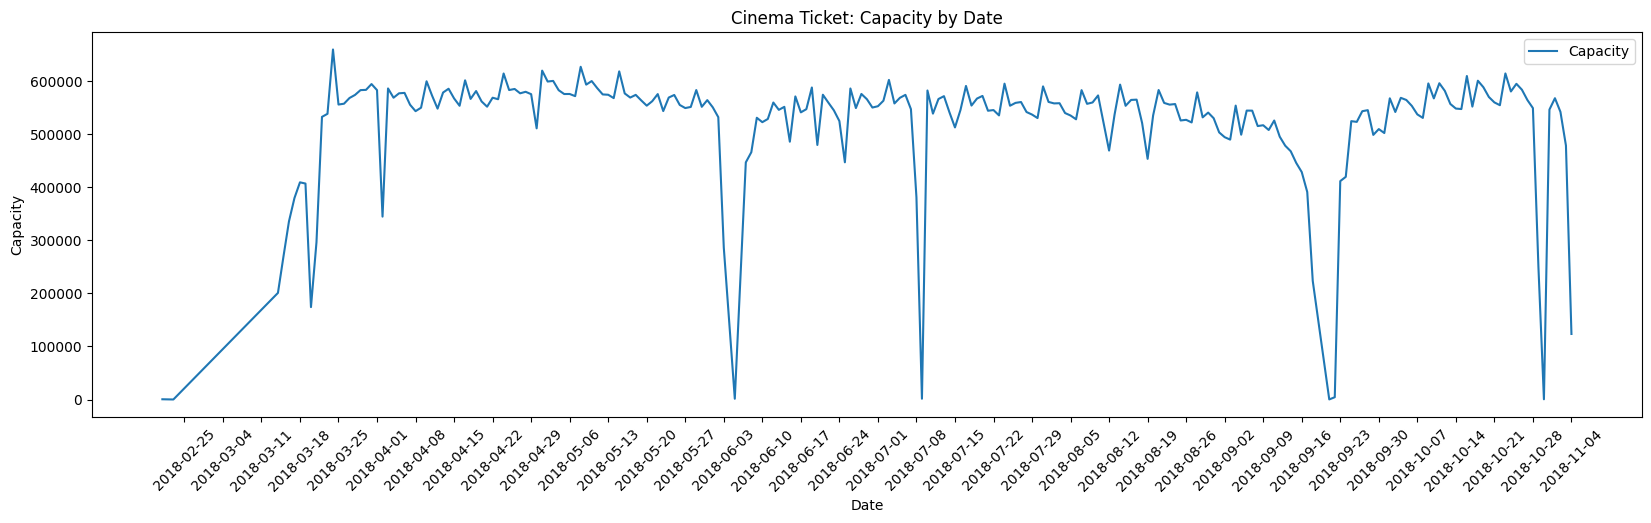

In [11]:
for col in df.columns:
    label = (col.replace("_", " ")).title()
    matplotlib.pyplot.plot(df[col], label=label)
    matplotlib.pyplot.title(f"Cinema Ticket: {label} by Date")
    matplotlib.pyplot.xlabel("Date")
    matplotlib.pyplot.ylabel(label)
    matplotlib.pyplot.legend()
    matplotlib.pyplot.xticks(ticks=pandas.date_range(start=df.index[0], end=df.index[-1], freq="W"), rotation=45)
    matplotlib.pyplot.show()

**Seasonal Decomposition**

Seasonal Decomposition is calculated on one set of data points at a time. If you want to see the seasonal decomposition of each of the columns, then each column will need to have the value calculated. Looking at the plots above, the `ticket_use`, `occu_perc`, `total_sales`, and `tickets_sold` columns may not be good candidates. The movement of the data seems to be parabolic in nature, and not necessarily linear, which could cause some issues in the analysis. However, we will continue with the analysis, knowing that there may be better methods for analyzing the data. The best data for analysis might be the `total_sales` column, since one may want to see how the total sales changes over time.

Use [`seasonal_decompose()`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) from `statsmodels.tsa.seasonal` to separate the data of a single column into the separate components of the decomposition. The result of `seasonal_decompose()` will be the observed values, the trend, the seasonality, and the residuals of the analysis. The following are a brief explanation of the different parts of the seasonal decomposition:
   1. Level: The average value of the series. This is not shown in the plot of the `seasonal_decompose()` function.
   2. Trend: The long-term change in level within the series. It can be increasing, decreasing, or static.
   3. Seasonality: The regular and predictable change in the data. Repetition that can be seen in the data.
   4. Noise: The irregular or random fluctuation that cannot be explained. The residual. The error. The unexplainable variation in the data.

The method `seasonal_decompose()` accepts many parameters. Pass in `df.total_sales` for the data and use both the `model="additive"` or `model="multiplicative"`; I'll use both for explanation purposes. If the data already has an obvious periodicity, then the `period=` parameter can be left out. For this data, that is not possible, so we will pass in `period=12`, representing 12 months in a year. Save the results of `seasonal_decompose()` to `total_sales_decomposition` and plot it using `plot()` and then showing the results of the plot with `matplotlib.pyplot.show()`.

Time-series data is called a signal and can be represented as `y(t)`. The decomposition of `y(t)` breaks down into level, trend, seasonality, and noise. The additive model is represented by `y(t) = level(t) + trend(t) + seasonal(t) + noise(t)`. The multiplicative model is represented by `y(t) = level(t) * trend(t) * seasonal(t) * noise(t)`. The exact calculations for calculating each of these is outside the scope of this demonstration, but can be seen at this [link](https://towardsdatascience.com/time-series-decomposition-8f39432f78f9/).

There are a couple methods for determining whether or not an additive or multiplicative model should be use. The first is to look at the amplitude of the plot line. If it changes over time, then it is likely necessary to use a multiplicative model. Otherwise, the additive model will be the best. Looking at the line in `total_sales`, the amplitude changes a lot over time. This means the multiplicative model is likely the best. The other method is to plot the results of an addtive model and an multiplicative model. If the residuals are in a fairly straight line, then the model that produced the straight line is likely the best option. For the `total_sales` column, the residuals in the plots below are scattered for both models, so the multiplicative model will be used, knowing that the change in amplitude over time varies a lot.

The results of each model was saved to `total_sales_decomposition`. Since `total_sales_decomposition` contains the results of the multiplicative model, I will leave this. Otherwise, it would be necessary to save them under different names, if you wanted to use the results of both models for another kind of analysis. 

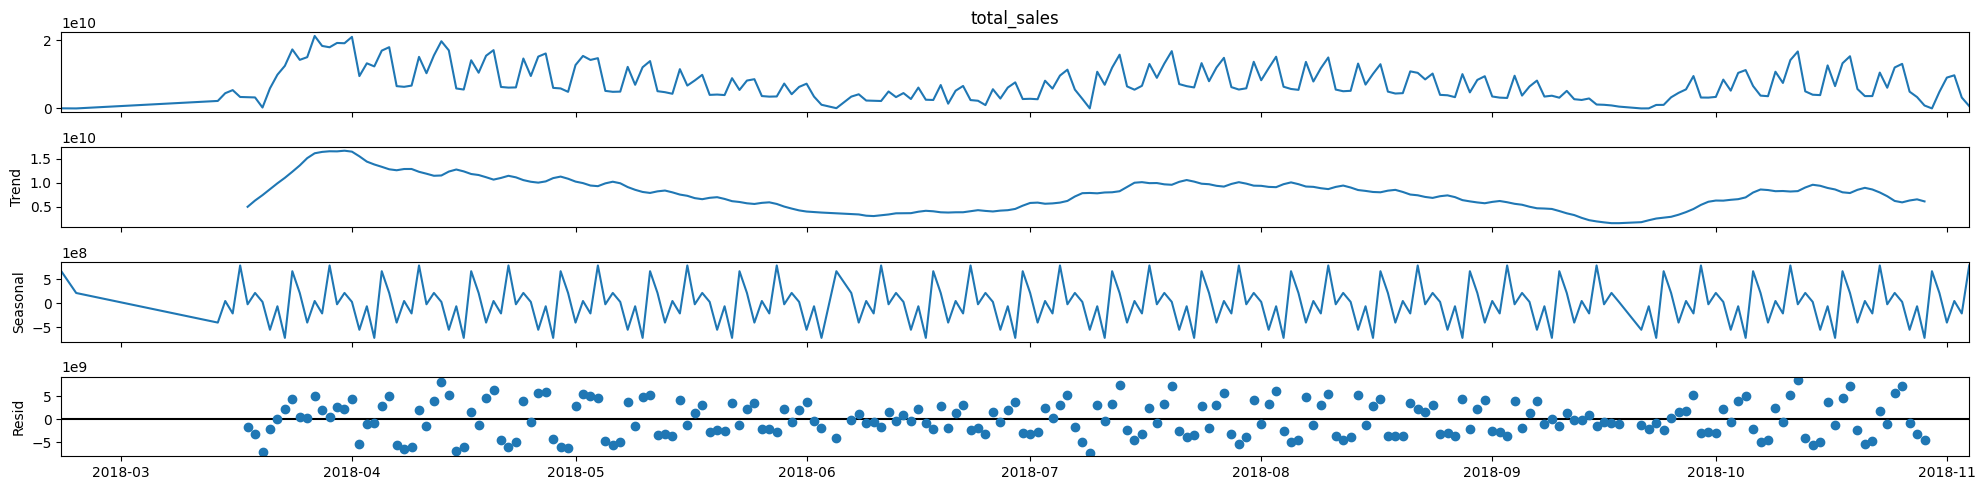

In [12]:
total_sales_decomposition = seasonal_decompose(df.total_sales, model="additive", period=12)
total_sales_decomposition.plot()
matplotlib.pyplot.show()

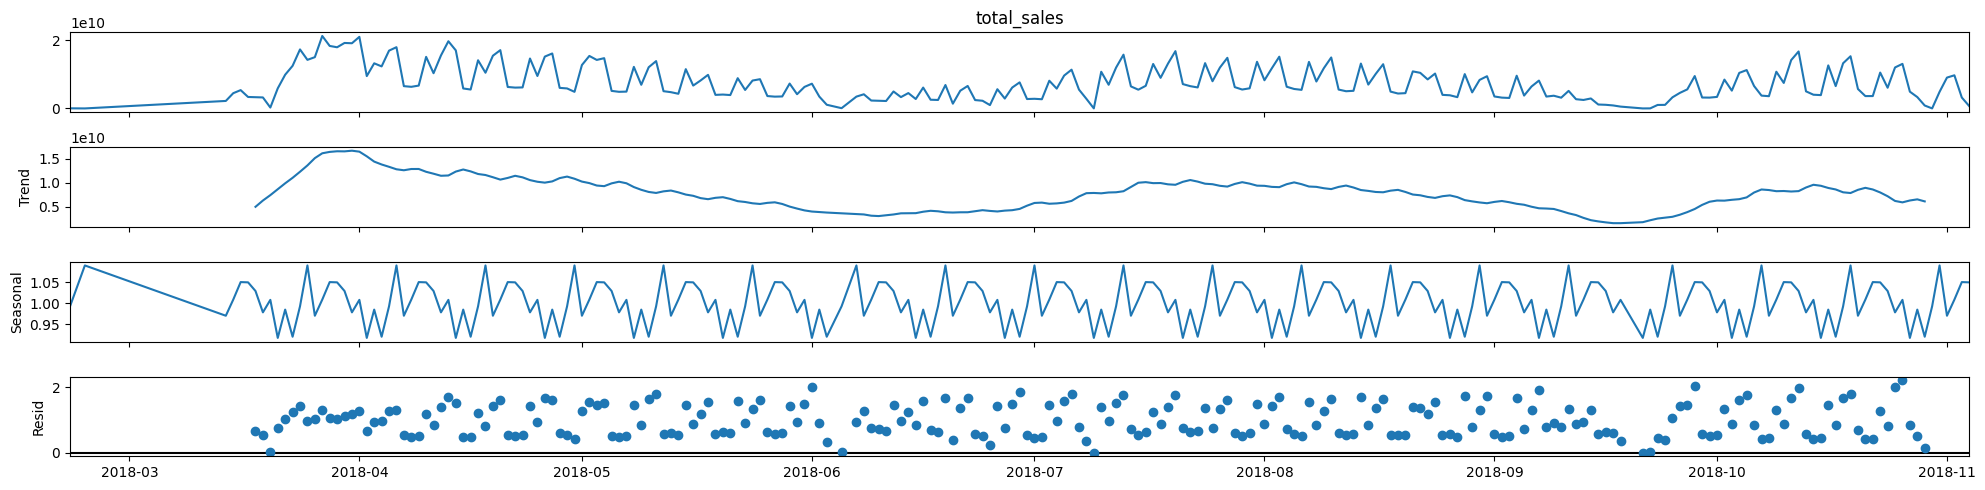

In [13]:
total_sales_decomposition = seasonal_decompose(df.total_sales, model="multiplicative", period=12)
total_sales_decomposition.plot()
matplotlib.pyplot.show()

Need to review periodicity of the time series data.

In [14]:
# df["trend"] = total_sales_decomposition.trend
# df["seasonal"] = total_sales_decomposition.seasonal
# df.dropna(inplace=True)
# df["month"] = df.index.month
# df["month"] = df["month"].astype(dtype="category")
# df = pandas.get_dummies(df, drop_first=True)
# df.head(n=15)